# Tratamento dos dados e criação dos csvs

## Bibliotecas

In [10]:
import pandas as pd
import polars as pl
pl.enable_string_cache()
pd.set_option('future.no_silent_downcasting', True)
import glob
import os
import joblib
from funcoes_de_tratamento import *
inst = joblib.load("../scalers/instituicoes_validas.joblib")
import matplotlib.pyplot as plt

windows = ["7-1", "7-2", "14-1", "14-3", "30-7"]
w = windows[1]

## Carregando os dados

1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
1. Python is running from: /home/ismael/Documentos/GRANULARITY-PREDICTION/src/notebooks
2. Is the target path valid? True

--- All dataframes loaded successfully! ---
Instituições com poucos dados: 5
Instituições com pelo menos 1 nulo: 0
Instituições com variância zero: 0
Instituições com valores negativos: 0
Instituições com outliers: 176
Instituições restantes: 102


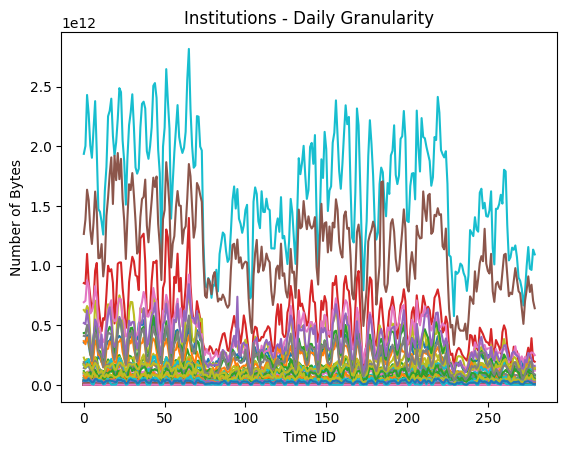

In [4]:


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_day'
#tempo_dia = pd.read_csv('../../data/times/times_1_day.csv')
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
# 2. Use glob to get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_dia = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_dia.append(df)

    #print(f"Loaded '{file}' as dataframe '{filename}'")

# --- Now you can access any dataframe by its filename ---
df_day = pd.concat(lista_dia, ignore_index=True)
del lista_dia
print("\n--- All dataframes loaded successfully! ---")


# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_1_hour'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_hora = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = str(os.path.splitext(os.path.basename(file))[0])
    
    # Read the CSV file and store it in the dictionary
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_hora.append(df)
df_hour = pd.concat(lista_hora, ignore_index=True)
del lista_hora
# --- Now you can access any dataframe by its filename ---
print("\n--- All dataframes loaded successfully! ---")



# 1. Specify the path to the folder containing your CSV files
#    Remember to change this to your actual folder path!
path = '../../data/institutions/agg_10_minutes'
print(f"1. Python is running from: {os.getcwd()}")
print(f"2. Is the target path valid? {os.path.exists(path)}")
csv_files = glob.glob(os.path.join(path, "*.csv"))

# 3. Create an empty dictionary to store the dataframes
lista_min = []
# 4. Loop through the list of CSV files
for file in csv_files:
    # Get the filename without the extension to use as a dictionary key
    # For example, 'path/to/data.csv' becomes 'data'
    filename = os.path.splitext(os.path.basename(file))[0]
    
    
    df = pd.read_csv(file)
    df = df[["id_time","n_bytes"]].sort_values(by='id_time')
    df["id_institution"] = filename
    lista_min.append(df)

# --- Now you can access any dataframe by its filename ---
df_10min = pd.concat(lista_min, ignore_index=True)
del lista_min
print("\n--- All dataframes loaded successfully! ---")


##############################################################################################

#analise dos dados diários
inst = []
p_d = 0
val_null = 0
var_z = 0
val_neg = 0
out = 0
for i in df_day["id_institution"].unique():
    instituicao = df_day[df_day["id_institution"]==i]
    serve = True
    Q1 = instituicao["n_bytes"].quantile(0.20)
    Q3 = instituicao["n_bytes"].quantile(0.80)
    IQR = Q3 - Q1
    L_inferior = Q1 - 1.5*IQR
    L_superior = Q3 + 1.5*IQR

    #verifica se ha instituições com poucos dados e elimina elas se for o caso
    if instituicao.shape[0] < 260:
        #print(f"{i} tem poucos dados")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        p_d += 1

    #verifica se ha instituições com valores nulos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"].isnull()].shape[0]>0:
        #print(f"{i} tem valores nulos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_null += 1

    #verifica se ha instituições com variância zero e elimina elas se for o caso
    elif instituicao["n_bytes"].var() == 0:
        #print(f"{i} tem variância zero")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        var_z += 1

    #verifica se ha instituições com valores negativos e elimina elas se for o caso
    elif instituicao[instituicao["n_bytes"]<0].shape[0]>0:
        #print(f"{i} tem valores negativos")
        #df_day = df_day[df_day["id_institution"]!=i]
        serve = False
        val_neg += 1

    #verifica se ha instituições com outliers (valores muito altos) e elimina elas se for o caso
    elif instituicao[(instituicao["n_bytes"] > L_superior) | (instituicao["n_bytes"] < L_inferior)].shape[0]>0:
        serve = False
        out += 1


    if serve:
        inst.append(i)

print(f"Instituições com poucos dados: {p_d}")
print(f"Instituições com pelo menos 1 nulo: {val_null}")
print(f"Instituições com variância zero: {var_z}")
print(f"Instituições com valores negativos: {val_neg}")
print(f"Instituições com outliers: {out}")
print(f"Instituições restantes: {len(inst)}")
inst.remove('243')
for i in inst:
    instituicao = df_day[df_day["id_institution"]==i]
    
    plt.plot(instituicao["id_time"], instituicao["n_bytes"], label=i)
plt.title(f"Institutions - Daily Granularity")
plt.xlabel("Time ID")
plt.ylabel("Number of Bytes")
plt.show()

df_day = df_day[df_day["id_institution"].isin(inst)]
df_hour = df_hour[df_hour["id_institution"].isin(inst)]
df_10min = df_10min[df_10min["id_institution"].isin(inst)]




joblib.dump(inst, "../scalers/instituicoes_validas.joblib")
  
print()

## Tratamento de dados

In [5]:


# 1. Leituras
time_day = pl.read_csv('../../data/times/times_1_day.csv')
time_hour = pl.read_csv('../../data/times/times_1_hour.csv')
time_minute = pl.read_csv('../../data/times/times_10_minutes.csv')

# 2. Conversão de Tipos
df_day = pl.from_pandas(df_day).with_columns(pl.col("id_time").cast(pl.Int64))
df_hour = pl.from_pandas(df_hour).with_columns(pl.col("id_time").cast(pl.Int64))
df_10min = pl.from_pandas(df_10min).with_columns(pl.col("id_time").cast(pl.Int64))

# -----------------------
# PROCESSAMENTO DF_DAY
# -----------------------
df_day = (
    df_day.join(time_day, on="id_time", how="left")
    .with_columns(pl.col("time").str.to_datetime(time_zone="UTC")) # <--- AQUI
    .with_columns(pl.col("time").dt.date().alias("time_day"))
    .with_columns(
        (pl.col("id_institution").cast(pl.Utf8) + "_" + pl.col("time_day").cast(pl.Utf8)).alias("ID")
    )
    .drop(["id_time", "time"])
    .rename({"n_bytes": "n_bytes_day"})
)
del time_day

# -----------------------
# PROCESSAMENTO DF_HOUR
# -----------------------
df_hour = (
    df_hour.join(time_hour, on="id_time", how="left")
    .with_columns(pl.col("time").str.to_datetime(time_zone="UTC")) # <--- AQUI
    .with_columns(
        pl.col("time").dt.date().alias("time_day"),
        pl.col("time").dt.hour().alias("hour_id")
    )
    .with_columns(
        (pl.col("id_institution").cast(pl.Utf8) + "_" + pl.col("time_day").cast(pl.Utf8)).alias("ID")
    )
    .drop(["id_time", "time", "id_institution"])
    .rename({"n_bytes": "n_bytes_hour"})
)
del time_hour

# -----------------------
# PROCESSAMENTO DF_10MIN
# -----------------------
df_10min = (
    df_10min.join(time_minute, on="id_time", how="left")
    .with_columns(pl.col("time").str.to_datetime(time_zone="UTC")) # <--- AQUI
    .with_columns(
        (pl.col("id_institution").cast(pl.Utf8) + "_" + pl.col("time").dt.date().cast(pl.Utf8)).alias("ID"),
        (pl.col("time").dt.minute() // 10).cast(pl.Int64).alias("min_id"),
        pl.col("time").dt.second().alias("sec_id")
    )
    .drop(["id_time", "time", "id_institution"])
    .rename({"n_bytes": "n_bytes_10minutes"})
)
del time_minute

# -----------------------
# MERGES MESTRES
# -----------------------
# O Polars não cria sufixos duplicados para a esquerda como o Pandas (time_day_day e time_day_hour). 
# Ele mantém a esquerda intacta (time_day) e adiciona o sufixo à direita.
df_merged = df_day.join(df_hour, on="ID", how="left", suffix="_hour")
df_merged = df_merged.join(df_10min, on="ID", how="left")

# Simulando a queda exata das colunas redundantes do Pandas
df_merged = df_merged.drop(["time_day", "time_day_hour"])

# Chamada da função Polars refatorada anteriormente
df_completo = complete_id(df_merged)
del df_merged

# -----------------------
# FATIAMENTO FINAL
# -----------------------
# Nota: No Polars, o .copy() é desnecessário porque a biblioteca já é Imutável / Zero-copy. 
# O .drop_duplicates() vira a função nativa .unique().

df_day = (
    df_completo.select(["ID", "id_institution", "n_bytes_day"])
    .unique()
    .rename({"n_bytes_day": "n_bytes"})
)

df_hour = (
    df_completo.select(["ID", "id_institution", "hour_id", "n_bytes_hour"])
    .unique()
    .with_columns((pl.col("ID") + "_" + pl.col("hour_id").cast(pl.Utf8)).alias("ID"))
    .drop("hour_id")
    .rename({"n_bytes_hour": "n_bytes"})
)

df_10min = (
    df_completo.select(["id_institution", "hour_id", "min_id", "n_bytes_10minutes"])
    .unique()
    .rename({"n_bytes_10minutes": "n_bytes"})
)

In [ ]:
df_day.to_csv("../../data/institutions/processed/df_day.csv", index=False)
df_hour.to_csv("../../data/institutions/processed/df_hour.csv", index=False)
df_10min.to_csv("../../data/institutions/processed/df_10min.csv", index=False)

In [ ]:
df_day = pd.read_csv("../../data/institutions/processed/df_day.csv")
df_day["id_institution"] = df_day["id_institution"].astype(np.float64).fillna(30).astype(np.int16).astype(str)
df_hour = pd.read_csv("../../data/institutions/processed/df_hour.csv")
df_hour["id_institution"] = df_hour["id_institution"].astype(np.float64).fillna(30).astype(np.int16).astype(str)

df_10min = pd.read_csv("../../data/institutions/processed/df_10min.csv")
df_10min["id_institution"] = df_10min["id_institution"].astype(np.float64).fillna(30).astype(np.int16).astype(str)

## Tratando [DIA] e separando em treino, val e teste

In [14]:


caminho_arquivo = '../scalers/scalers_hour.joblib'
if w == windows[0]:
    inputs_day = 7
    outputs_day = 1
elif w == windows[1]:
    inputs_day = 7
    outputs_day = 2
elif w == windows[2]:
    inputs_day = 14
    outputs_day = 1
elif w == windows[3]:
    inputs_day = 14
    outputs_day = 3
elif w == windows[4]:
    inputs_day = 30
    outputs_day = 7
x_cols = [f"x_{j}" for j in range(inputs_day)]
y_cols = [f"y_{o}" for o in range(outputs_day)]

train_list = []
val_list = []
test_list = []
scalers_day = {}

# 1. Transição imediata de Pandas para Polars na memória RAM
df_pl = df_day

for i in inst:
    print(i)
    
    # 2. Filtragem e Tratamento Nativo Polars (Muito mais rápido que Pandas)
    # Equivalente ao df[df == i]["n_bytes"].fillna(0).astype(float32)
    serie_pl = (
        df_pl.filter(pl.col("id_institution") == i)
        .get_column("n_bytes")
        .fill_null(0)
        .cast(pl.Float32)
    )
    
    tamanho = serie_pl.len() 
    
    if tamanho > 10*(inputs_day + outputs_day):
        
        # Ponte para as suas funções customizadas (que assumem Pandas/NumPy)
        serie_numpy = serie_pl
        
        _train_day, _val_day, _test_day = treino_val_teste(serie_numpy, 0.6, 0.1, 1-0.6-0.1)
        train_day, scaler = scaling(_train_day, 0)
        scalers_day[i] = scaler
        test_day = scaling(_test_day, 1, scaler)
        val_day = scaling(_val_day, 1, scaler)
        
        # Roda o janelamento
        train_day_ = sliding_window(df_series=train_day, inputs=inputs_day, outputs=outputs_day, step= 5)
        test_day_ = sliding_window(df_series=test_day, inputs=inputs_day, outputs=outputs_day)
        val_day_ = sliding_window(df_series=val_day, inputs=inputs_day, outputs=outputs_day, step = 5)
        
        # 3. Converte a janela de volta para Polars e insere a coluna 'id_institution'

        
        train_list.append(train_day_.select(pl.lit(i).alias("id_institution"), pl.all()))
        test_list.append(test_day_.select(pl.lit(i).alias("id_institution"), pl.all()))
        val_list.append(val_day_.select(pl.lit(i).alias("id_institution"), pl.all()))
        
    else: 
        print(f"   dataset pequeno ({tamanho})")

# 4. Concatenação de alta performance (Evita o estouro de RAM que o pd.concat causa)
print("\nConcatenando matrizes no Polars...")
train_day_wind = pl.concat(train_list, how="vertical")
val_day_wind = pl.concat(val_list, how="vertical")
test_day_wind = pl.concat(test_list, how="vertical")

del train_list, val_list, test_list

# Move a coluna 'id_institution' para ser a primeira da esquerda
cols = ["id_institution"] + [c for c in train_day_wind.columns if c != "id_institution"]
train_day_wind = train_day_wind.select(cols)
val_day_wind = val_day_wind.select(cols)
test_day_wind = test_day_wind.select(cols)

# 5. Salvamento Multithread
print("Salvando no disco...")
train_day_wind.write_csv('../../data/Tabelas_criadas/'+w+'/treino_day.csv')
test_day_wind.write_csv('../../data/Tabelas_criadas/'+w+'/teste_day.csv')
val_day_wind.write_csv('../../data/Tabelas_criadas/'+w+'/val_day.csv')
joblib.dump(scalers_day, caminho_arquivo)
print("Finalizado!")

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104

Concatenando matrizes no Polars...
Salvando no disco...
Finalizado!


## Tratando [HORAS] e separando em treino, val e teste

In [15]:


caminho_arquivo = '../scalers/scalers_hour.joblib'
if w == windows[0]:
    inputs_hour = 7*24
    outputs_hour = 1*24
elif w == windows[1]:
    inputs_hour = 7*24
    outputs_hour = 2*24
elif w == windows[2]:
    inputs_hour = 14*24
    outputs_hour = 1*24
elif w == windows[3]:
    inputs_hour = 14*24
    outputs_hour = 3*24
elif w == windows[4]:
    inputs_hour = 30*24
    outputs_hour = 7*24
x_cols = [f"x_{j}" for j in range(inputs_hour)]
y_cols = [f"y_{o}" for o in range(outputs_hour)]

train_list = []
val_list = []
test_list = []
scalers_hour = {}

# 1. Transição imediata de Pandas para Polars na memória RAM
df_pl = df_hour

for i in inst:
    print(i)
    
    # 2. Filtragem e Tratamento Nativo Polars (Muito mais rápido que Pandas)
    # Equivalente ao df[df == i]["n_bytes"].fillna(0).astype(float32)
    serie_pl = (
        df_pl.filter(pl.col("id_institution") == i)
        .get_column("n_bytes")
        .fill_null(0)
        .cast(pl.Float32)
    )
    
    tamanho = serie_pl.len() 
    
    if tamanho > 10*(inputs_hour + outputs_hour):
        
        # Ponte para as suas funções customizadas (que assumem Pandas/NumPy)
        serie_numpy = serie_pl
        
        _train_hour, _val_hour, _test_hour = treino_val_teste(serie_numpy, 0.6, 0.1, 1-0.6-0.1)
        train_hour, scaler = scaling(_train_hour, 0)
        scalers_hour[i] = scaler
        test_hour = scaling(_test_hour, 1, scaler)
        val_hour = scaling(_val_hour, 1, scaler)
        
        # Roda o janelamento
        train_hour_ = sliding_window(df_series=train_hour, inputs=inputs_hour, outputs=outputs_hour, step= 5)
        test_hour_ = sliding_window(df_series=test_hour, inputs=inputs_hour, outputs=outputs_hour)
        val_hour_ = sliding_window(df_series=val_hour, inputs=inputs_hour, outputs=outputs_hour, step = 5)
        
        # 3. Converte a janela de volta para Polars e insere a coluna 'id_institution'

        
        train_list.append(train_hour_.select(pl.lit(i).alias("id_institution"), pl.all()))
        test_list.append(test_hour_.select(pl.lit(i).alias("id_institution"), pl.all()))
        val_list.append(val_hour_.select(pl.lit(i).alias("id_institution"), pl.all()))
        
    else: 
        print(f"   dataset pequeno ({tamanho})")

# 4. Concatenação de alta performance (Evita o estouro de RAM que o pd.concat causa)
print("\nConcatenando matrizes no Polars...")
train_hour_wind = pl.concat(train_list, how="vertical")
val_hour_wind = pl.concat(val_list, how="vertical")
test_hour_wind = pl.concat(test_list, how="vertical")

del train_list, val_list, test_list

# Move a coluna 'id_institution' para ser a primeira da esquerda
cols = ["id_institution"] + [c for c in train_hour_wind.columns if c != "id_institution"]
train_hour_wind = train_hour_wind.select(cols)
val_hour_wind = val_hour_wind.select(cols)
test_hour_wind = test_hour_wind.select(cols)

# 5. Salvamento Multithread
print("Salvando no disco...")
train_hour_wind.write_csv('../../data/Tabelas_criadas/'+w+'/treino_hour.csv')
test_hour_wind.write_csv('../../data/Tabelas_criadas/'+w+'/teste_hour.csv')
val_hour_wind.write_csv('../../data/Tabelas_criadas/'+w+'/val_hour.csv')
joblib.dump(scalers_hour, caminho_arquivo)
print("Finalizado!")

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104

Concatenando matrizes no Polars...
Salvando no disco...
Finalizado!


## Tratando [MINUTOS] e separando em treino, val e teste
por enquano, este vai ficar de escanteio por precisar de um tratamento mais especifico


In [16]:
import numpy as np
caminho_arquivo = '../scalers/scalers_10min.joblib'
if w == windows[0]:
    inputs_10min = 7*24*6
    outputs_10min = 1*24*6
elif w == windows[1]:
    inputs_10min = 7*24*6
    outputs_10min = 2*24*6
elif w == windows[2]:
    inputs_10min = 14*24*6
    outputs_10min = 1*24*6
elif w == windows[3]:
    inputs_10min = 14*24*6
    outputs_10min = 3*24*6
elif w == windows[4]:
    inputs_10min = 30*24*6
    outputs_10min = 7*24*6
x_cols = [f"x_{j}" for j in range(inputs_10min)]
y_cols = [f"y_{o}" for o in range(outputs_10min)]

train_list = []
val_list = []
test_list = []
scalers_10min = {}

# 1. Transição imediata de Pandas para Polars na memória RAM
df_pl = df_10min

for i in inst:
    print(i)
    
    # 2. Filtragem e Tratamento Nativo Polars (Muito mais rápido que Pandas)
    # Equivalente ao df[df == i]["n_bytes"].fillna(0).astype(float32)
    serie_pl = (
        df_pl.filter(pl.col("id_institution") == i)
        .get_column("n_bytes")
        .fill_null(0)
        .cast(pl.Float32)
    )
    
    tamanho = serie_pl.len() 
    
    if tamanho > 10*(inputs_10min + outputs_10min):
        
        # Ponte para as suas funções customizadas (que assumem Pandas/NumPy)
        serie_numpy = serie_pl
        
        _train_10min, _val_10min, _test_10min = treino_val_teste(serie_numpy, 0.6, 0.1, 1-0.6-0.1)
        train_10min, scaler = scaling(_train_10min, 0)
        scalers_10min[i] = scaler
        test_10min = scaling(_test_10min, 1, scaler)
        val_10min = scaling(_val_10min, 1, scaler)
        
        # Roda o janelamento
        train_10min_ = sliding_window(df_series=train_10min, inputs=inputs_10min, outputs=outputs_10min, step= 5)
        test_10min_ = sliding_window(df_series=test_10min, inputs=inputs_10min, outputs=outputs_10min)
        val_10min_ = sliding_window(df_series=val_10min, inputs=inputs_10min, outputs=outputs_10min, step = 5)
        
        # 3. Converte a janela de volta para Polars e insere a coluna 'id_institution'

        
        train_list.append(train_10min_.select(pl.lit(i).alias("id_institution"), pl.all()))
        test_list.append(test_10min_.select(pl.lit(i).alias("id_institution"), pl.all()))
        val_list.append(val_10min_.select(pl.lit(i).alias("id_institution"), pl.all()))
        
    else: 
        print(f"   dataset pequeno ({tamanho})")

# 4. Concatenação de alta performance (Evita o estouro de RAM que o pd.concat causa)
print("\nConcatenando matrizes no Polars...")
train_10min_wind = pl.concat(train_list, how="vertical")
val_10min_wind = pl.concat(val_list, how="vertical")
test_10min_wind = pl.concat(test_list, how="vertical")

del train_list, val_list, test_list

# Move a coluna 'id_institution' para ser a primeira da esquerda
cols = ["id_institution"] + [c for c in train_10min_wind.columns if c != "id_institution"]
train_10min_wind = train_10min_wind.select(cols)
val_10min_wind = val_10min_wind.select(cols)
test_10min_wind = test_10min_wind.select(cols)

# 5. Salvamento Multithread
print("Salvando no disco...")
train_10min_wind.write_csv('../../data/Tabelas_criadas/'+w+'/treino_10min.csv')
test_10min_wind.write_csv('../../data/Tabelas_criadas/'+w+'/teste_10min.csv')
val_10min_wind.write_csv('../../data/Tabelas_criadas/'+w+'/val_10min.csv')
joblib.dump(scalers_10min, caminho_arquivo)
print("Finalizado!")

68
130
64
3
41
117
151
74
239
10
70
119
94
4
203
115
72
249
50
54
223
83
164
265
69
42
39
65
62
114
218
165
9
132
38
8
53
102
105
0
222
200
175
235
147
5
284
45
52
67
126
59
71
46
144
244
108
73
27
109
63
208
32
30
185
179
86
216
209
34
138
101
23
214
136
48
145
22
107
60
88
230
113
224
57
196
95
254
80
124
207
161
219
240
225
149
158
56
137
93
104

Concatenando matrizes no Polars...
Salvando no disco...
Finalizado!
